# HNSW 在 NetVLAD 特征上的性能分析（余弦相似度 / 内积）

NetVLAD 描述子本身已归一化（模长≈1），**直接使用内积** 即等价于余弦相似度，无需再 L2 归一化。
参考 run_hnsw_hmm，用 `IndexFlatIP` / `IndexHNSWFlat(METRIC_INNER_PRODUCT)` 在原始描述子上做暴力检索与 HNSW 检索，比较 Recall 与检索时间。

In [4]:
import sys
from pathlib import Path

# 确保能导入 ch3 下的 demo_readH5（若 kernel 的 cwd 是 hnsw_performance_analysis）
_nb_dir = Path().resolve()
if _nb_dir.name == "hnsw_performance_analysis":
    sys.path.insert(0, str(_nb_dir.parent))

import numpy as np
import faiss
import matplotlib.pyplot as plt
import time

from demo_readH5 import load_netvlad_descriptors, load_multi_netvlad_descriptors, DB_H5_PATHS, QUERY_H5_PATHS
from scene_config import get_db_scene_ranges, get_query_trajectory_ranges, DATASETS_BASE
from coords_gt_utils import build_database_coords, build_gt_9_for_all_trajectories

## 1. 读取 NetVLAD H5（合并多个 DB 文件）

In [5]:
# 将多个 DB H5 合并为一个大数据库
print("从多个 DB H5 读取并合并 NetVLAD 描述子...")
db_names, db_descs = load_multi_netvlad_descriptors(DB_H5_PATHS)

print("从多个 Query H5 读取并合并 NetVLAD 描述子...")
query_names, query_descs = load_multi_netvlad_descriptors(QUERY_H5_PATHS)

db_descs = db_descs.astype(np.float32)
query_descs = query_descs.astype(np.float32)

N_db, D = db_descs.shape
n_queries = query_descs.shape[0]
trajectory_ranges = get_query_trajectory_ranges(QUERY_H5_PATHS)
db_scene_ranges = get_db_scene_ranges(DB_H5_PATHS, db_names)

print(f"DB (multi):    {N_db} 条, shape {db_descs.shape}")
print(f"Query (multi): {n_queries} 条, 共 {len(trajectory_ranges)} 条轨迹")

# 输出前 10 个 NetVLAD 向量的模长
n_show = min(10, len(db_descs))
db_norms = np.linalg.norm(db_descs[:n_show], axis=1)
print(f"\n前 {n_show} 个 DB NetVLAD 向量的模长:")
for i in range(n_show):
    print(f"  [{i}] {db_names[i]}: {db_norms[i]:.6f}")

从多个 DB H5 读取并合并 NetVLAD 描述子...
从多个 Query H5 读取并合并 NetVLAD 描述子...
DB (multi):    11009 条, shape (11009, 4096)
Query (multi): 5988 条, 共 15 条轨迹

前 10 个 DB NetVLAD 向量的模长:
  [0] tif/100_856_1006.tif: 1.000006
  [1] tif/101_1006_1006.tif: 0.999992
  [2] tif/102_1156_1006.tif: 1.000004
  [3] tif/103_1306_1006.tif: 1.000004
  [4] tif/104_1456_1006.tif: 0.999992
  [5] tif/105_1606_1006.tif: 1.000007
  [6] tif/106_1756_1006.tif: 0.999994
  [7] tif/107_1906_1006.tif: 1.000004
  [8] tif/108_2056_1006.tif: 1.000005
  [9] tif/109_2206_1006.tif: 0.999994


## 2. 坐标法 GT@25（与 run_hnsw_hmm 一致）

参考 run_hnsw_hmm：基于 uav_infos.csv 经纬度 + GDAL，每 query 取方圆 25 张 DB 子图作为真值。

In [116]:
# 坐标法 GT@25（与 run_hnsw_hmm 一致）
print("构建 database_coords（GDAL + id_startx_starty）...")
database_coords = build_database_coords(db_names, db_scene_ranges, DATASETS_BASE)
n_valid = np.sum(~np.any(np.isnan(database_coords), axis=1))
print(f"有效坐标: {n_valid}/{N_db}")

print("构建坐标法 GT@25（每 query 方圆 25 张）...")
gt_9_list, gt_25_ordered = build_gt_9_for_all_trajectories(
    trajectory_ranges,
    db_scene_ranges,
    db_names,
    DATASETS_BASE,
)
n_with_gt = sum(1 for s in gt_9_list if len(s) > 0)
print(f"有 GT 的 query 数: {n_with_gt}/{len(gt_9_list)}")
if n_with_gt > 0:
    sizes = [len(s) for s in gt_9_list if len(s) > 0]
    print(f"GT 集合大小: min={min(sizes)}, max={max(sizes)}, mean={sum(sizes)/len(sizes):.1f}  (若 max>9 说明已按 25 张生成)")
    i0 = next(i for i in range(len(gt_9_list)) if len(gt_9_list[i]) > 0)
    try:
        if i0 < len(gt_25_ordered) and gt_25_ordered[i0] and isinstance(gt_25_ordered[i0][0], (int, np.integer)):
            gt0 = list(gt_25_ordered[i0])
        else:
            gt0 = sorted(gt_9_list[i0])
    except NameError:
        gt0 = sorted(gt_9_list[i0])
    print(f"\n第一张有 GT 的 query（index={i0}）的 25 张 GT 图片:")
    for j, idx in enumerate(gt0):
        idx = int(idx) if not isinstance(idx, (int, np.integer)) else idx
        name = db_names[idx] if idx < len(db_names) else f"<{idx}>"
        print(f"  [{j+1:2d}] {name}")

# 仅对有效 query 评估
valid = np.array([len(gt_9_list[i]) > 0 for i in range(n_queries)], dtype=bool)
valid_indices = np.where(valid)[0]

# 算指标时排除 industry2 和 rural2
exclude_scenes = {"industry2", "rural2"}
exclude_mask = np.zeros(n_queries, dtype=bool)
for scene_name, start, end in trajectory_ranges:
    if scene_name in exclude_scenes:
        exclude_mask[start:end] = True
valid_for_metrics = valid & ~exclude_mask

构建 database_coords（GDAL + id_startx_starty）...
=== database_coords 各场景（未算出坐标的会打印原因）===
  [city1] 共 342 条 -> 有效坐标 342/342
  [city2] 共 168 条 -> 有效坐标 168/168
  [city3] 共 224 条 -> 有效坐标 224/224
  [industry1] 共 868 条 -> 有效坐标 868/868
  [industry2] 共 414 条 -> 有效坐标 414/414
  [industry3] 共 1476 条 -> 有效坐标 1476/1476
  [park1] 共 324 条 -> 有效坐标 324/324
  [rural1] 共 1845 条 -> 有效坐标 1845/1845
  [rural2] 共 1845 条 -> 有效坐标 1845/1845
  [rural3] 共 399 条 -> 有效坐标 399/399
  [school] 共 1178 条 -> 有效坐标 1178/1178
  [suburbs1] 共 480 条 -> 有效坐标 480/480
  [suburbs2] 共 468 条 -> 有效坐标 468/468
  [village1] 共 285 条 -> 有效坐标 285/285
  [village2] 共 693 条 -> 有效坐标 693/693
  -> 合计有效坐标: 11009/11009

有效坐标: 11009/11009
构建坐标法 GT@25（每 query 方圆 25 张）...
=== 坐标法 GT@25 各轨迹（未算出 GT 的会打印原因）===

--- 坐标法 GT 首帧诊断 [city1] ---
大图 mapbox geotransform (6 参数):
  gt[0] 左上角 X (投影/经度): 12123218.434142068
  gt[1] 像元宽:               0.2985821417389691
  gt[2] 旋转(常为 0):         0.0
  gt[3] 左上角 Y (投影/纬度): 4062398.742272254
  gt[4] 旋转(常为 0):         0.0
  

## 3. Recall@k 与 HNSW 构建/检索辅助函数（内积索引）

In [117]:
def recall_at_k(pred_I: np.ndarray, gt_9_list: list, k: int, valid: np.ndarray = None) -> float:
    """坐标法 GT：pred_I (N_q, topk)，gt_9_list 每 query 为 DB 索引集合。仅对有 GT 的 query 计算 Recall@k。"""
    nq = pred_I.shape[0]
    if valid is None:
        valid = np.ones(nq, dtype=bool)
    hit = 0
    count = 0
    for i in range(nq):
        if not valid[i] or len(gt_9_list[i]) == 0:
            continue
        gt_set = set(int(x) for x in gt_9_list[i])
        pred_topk = pred_I[i, :k]
        pred_valid = [int(p) for p in pred_topk if p >= 0]
        if any(p in gt_set for p in pred_valid):
            hit += 1
        count += 1
    return float(hit / count) if count > 0 else 0.0


def build_hnsw_and_search_cosine(db: np.ndarray, q: np.ndarray, k: int, M: int, ef_c: int, ef_s: int):
    """在原始 NetVLAD 描述子上构建 HNSW（内积），与 run_hnsw_hmm 一致，等价于余弦相似度。"""
    d = db.shape[1]
    index = faiss.IndexHNSWFlat(d, M, faiss.METRIC_INNER_PRODUCT)
    index.hnsw.efConstruction = ef_c
    index.hnsw.efSearch = ef_s
    t0 = time.perf_counter()
    index.add(db)
    t_build = time.perf_counter() - t0
    t1 = time.perf_counter()
    D, I = index.search(q, k)
    t_search = time.perf_counter() - t1
    return index, I, D, t_build, t_search

In [118]:
# 统一结果输出目录（相对当前 notebook 路径）
results_root = Path("results/hnsw_analysis/")
results_root.mkdir(exist_ok=True)


def save_hnsw_results(index, I, D, db_names, query_names, tag: str):
    """保存 HNSW 索引和检索结果到 results_cosine 目录。"""
    # 保存索引
    index_path = results_root / f"hnsw_cosine_{tag}.index"
    faiss.write_index(index, str(index_path))

    # 保存检索结果 txt：每行 query_name db_name distance
    txt_path = results_root / f"hnsw_cosine_{tag}.txt"
    with txt_path.open("w", encoding="utf-8") as f:
        num_queries, topk = I.shape
        for qi in range(num_queries):
            q_name = query_names[qi]
            for rank in range(topk):
                db_idx = I[qi, rank]
                dist = D[qi, rank]
                db_name = db_names[db_idx]
                f.write(f"{q_name} {db_name} {float(dist):.6f}\n")

## 3.1 暴力检索（Baseline）

新增暴力检索，给出暴力检索的性能指标：recall@1 recall@5 recall@10 query time

In [119]:
# 暴力检索：IndexFlatIP（内积，等价于余弦）作为 baseline
k_brute = 20
dim = db_descs.shape[1]
index_brute = faiss.IndexFlatIP(dim)
index_brute.add(db_descs)
t0 = time.perf_counter()
D_brute, I_brute = index_brute.search(query_descs, k_brute)
t_search_brute = time.perf_counter() - t0
t_per_query_ms = (t_search_brute / len(query_descs)) * 1000

r1_brute = recall_at_k(I_brute, gt_9_list, 1, valid_for_metrics)
r5_brute = recall_at_k(I_brute, gt_9_list, 5, valid_for_metrics)
r10_brute = recall_at_k(I_brute, gt_9_list, 10, valid_for_metrics)
r20_brute = recall_at_k(I_brute, gt_9_list, 20, valid_for_metrics)

print("=== 暴力检索（IndexFlatIP）性能指标 ===")
print(f"  Recall@1  = {r1_brute:.4f}")
print(f"  Recall@5  = {r5_brute:.4f}")
print(f"  Recall@10 = {r10_brute:.4f}")
print(f"  Query time = {t_per_query_ms:.4f} ms/query")

=== 暴力检索（IndexFlatIP）性能指标 ===
  Recall@1  = 0.5901
  Recall@5  = 0.7632
  Recall@10 = 0.8248
  Query time = 23.5160 ms/query


## 4. efSearch 网格搜索：Recall（相对余弦真值）与查询时间

In [129]:
# 小规模数据：M 和 efSearch 用相对较小的值即可
M_fixed = 24
ef_construction_fixed = 250
ef_search_values = [1, 5, 10, 20, 35, 50, 64,80, 100, 125, 150, 175, 200]
k_eval = 10# 需要 top-20 才能正确计算 Recall@10 和 Recall@20


In [121]:

recalls_ef = []
times_per_query_ms = []

for ef_s in ef_search_values:
    index, I, D, t_build, t_search = build_hnsw_and_search_cosine(
        db_descs, query_descs, k_eval,
        M=M_fixed, ef_c=ef_construction_fixed, ef_s=ef_s
    )
    r1 = recall_at_k(I, gt_9_list, 1, valid_for_metrics)
    r5 = recall_at_k(I, gt_9_list, 5, valid_for_metrics)
    r10 = recall_at_k(I, gt_9_list, 10, valid_for_metrics)
    r20 = recall_at_k(I, gt_9_list, 20, valid_for_metrics)
    recalls_ef.append(r10)
    t_pq = (t_search / len(query_descs)) * 1000
    times_per_query_ms.append(t_pq)
    print(f"efSearch={ef_s:4d}  Recall@1={r1:.4f}  Recall@5={r5:.4f}  Recall@10={r10:.4f} Recall@20={r20:.4f} time/query={t_pq:.4f} ms")

    # 保存索引和检索结果
    tag = f"M{M_fixed}_efc{ef_construction_fixed}_efs{ef_s}"
    # save_hnsw_results(index, I, D, db_names, query_names, tag)

recalls_ef = np.array(recalls_ef)
times_per_query_ms = np.array(times_per_query_ms)

efSearch=   1  Recall@1=0.3165  Recall@5=0.4167  Recall@10=0.4633 Recall@20=0.4977 time/query=0.0098 ms
efSearch=   5  Recall@1=0.4678  Recall@5=0.5531  Recall@10=0.6010 Recall@20=0.6458 time/query=0.0142 ms
efSearch=  10  Recall@1=0.5271  Recall@5=0.6411  Recall@10=0.6709 Recall@20=0.7144 time/query=0.0227 ms
efSearch=  20  Recall@1=0.5578  Recall@5=0.6948  Recall@10=0.7351 Recall@20=0.7630 time/query=0.0304 ms
efSearch=  35  Recall@1=0.5786  Recall@5=0.7236  Recall@10=0.7717 Recall@20=0.8037 time/query=0.0440 ms
efSearch=  50  Recall@1=0.5891  Recall@5=0.7394  Recall@10=0.7920 Recall@20=0.8297 time/query=0.0599 ms
efSearch=  64  Recall@1=0.5950  Recall@5=0.7477  Recall@10=0.8009 Recall@20=0.8404 time/query=0.0681 ms
efSearch=  80  Recall@1=0.6008  Recall@5=0.7530  Recall@10=0.8090 Recall@20=0.8510 time/query=0.0814 ms
efSearch= 100  Recall@1=0.6047  Recall@5=0.7606  Recall@10=0.8182 Recall@20=0.8600 time/query=0.1013 ms
efSearch= 125  Recall@1=0.6044  Recall@5=0.7604  Recall@10=0.819

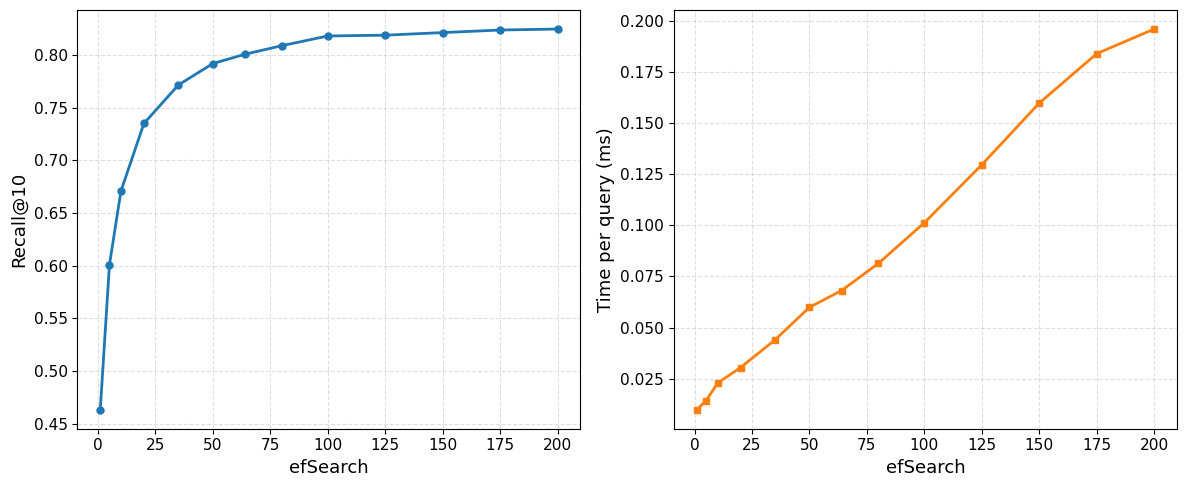

In [122]:
plt.rcParams.update({"font.size": 11})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=100)

ax1.plot(ef_search_values, recalls_ef, marker="o", markersize=5, linewidth=2)
ax1.set_xlabel("efSearch", fontsize=13)
ax1.set_ylabel("Recall@10", fontsize=13)
ax1.tick_params(axis="both", labelsize=11)
ax1.grid(True, alpha=0.4, linestyle="--")

ax2.plot(ef_search_values, times_per_query_ms, marker="s", markersize=5, linewidth=2, color="C1")
ax2.set_xlabel("efSearch", fontsize=13)
ax2.set_ylabel("Time per query (ms)", fontsize=13)
ax2.tick_params(axis="both", labelsize=11)
ax2.grid(True, alpha=0.4, linestyle="--")

plt.tight_layout()
fig.savefig("efsearch_recall_time.png", dpi=300, bbox_inches="tight")
plt.show()

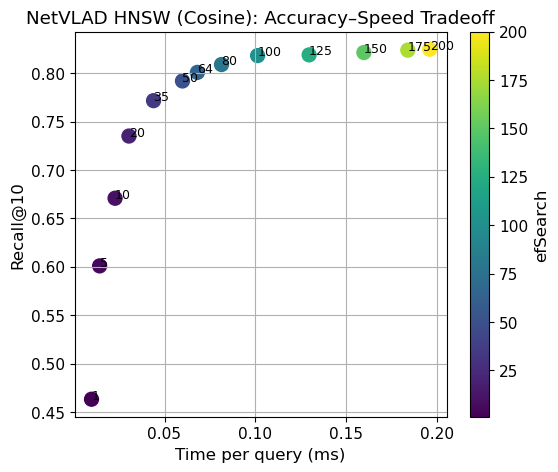

In [123]:
# 精度-速度权衡：Recall vs Time per query（余弦）
plt.figure(figsize=(6, 5))
plt.scatter(times_per_query_ms, recalls_ef, s=100, c=ef_search_values, cmap="viridis")
for i, ef in enumerate(ef_search_values):
    plt.annotate(str(ef), (times_per_query_ms[i], recalls_ef[i]), fontsize=9)
plt.xlabel("Time per query (ms)")
plt.ylabel("Recall@10")
plt.title("NetVLAD HNSW (Cosine): Accuracy–Speed Tradeoff")
plt.colorbar(label="efSearch")
plt.grid(True)
plt.show()

## 5. M 与 efConstruction 对（余弦）Recall 的影响

In [130]:
ef_search_fixed = 64
M_values = [8, 16, 24, 32, 64, 100, 132, 168, 208, 256]
ef_construction_values = [20, 50, 100, 150, 200, 250, 300, 350, 400]

results_M_efC = []  # list of (M, ef_c, recall, time_per_query_ms, index_size_mb)

for M in M_values:
    for ef_c in ef_construction_values:
        index, I, D, t_build, t_search = build_hnsw_and_search_cosine(
            db_descs, query_descs, k_eval,
            M=M, ef_c=ef_c, ef_s=ef_search_fixed
        )
        r = recall_at_k(I, gt_9_list, k_eval, valid_for_metrics)
        t_pq = (t_search / len(query_descs)) * 1000
        index_size_bytes = len(faiss.serialize_index(index))
        index_size_mb = index_size_bytes / (1024 * 1024)
        results_M_efC.append((M, ef_c, r, t_pq, index_size_mb))
        print(f"M={M}, efConstruction={ef_c}  Recall@{k_eval}={r:.4f}  time/query={t_pq:.4f} ms  index_size={index_size_mb:.2f} MB")

        # 保存当前参数组合的索引和检索结果
        tag = f"M{M}_efc{ef_c}_efs{ef_search_fixed}"
        # save_hnsw_results(index, I, D, db_names, query_names, tag)

results_M_efC = np.array(results_M_efC)

M=8, efConstruction=20  Recall@10=0.5772  time/query=0.0273 ms  index_size=172.86 MB
M=8, efConstruction=50  Recall@10=0.6803  time/query=0.0364 ms  index_size=172.86 MB
M=8, efConstruction=100  Recall@10=0.7374  time/query=0.0408 ms  index_size=172.86 MB
M=8, efConstruction=150  Recall@10=0.7607  time/query=0.0423 ms  index_size=172.86 MB
M=8, efConstruction=200  Recall@10=0.7807  time/query=0.0503 ms  index_size=172.86 MB
M=8, efConstruction=250  Recall@10=0.7807  time/query=0.0470 ms  index_size=172.86 MB
M=8, efConstruction=300  Recall@10=0.7901  time/query=0.0487 ms  index_size=172.86 MB
M=8, efConstruction=350  Recall@10=0.7937  time/query=0.0512 ms  index_size=172.86 MB
M=8, efConstruction=400  Recall@10=0.7967  time/query=0.0538 ms  index_size=172.86 MB
M=16, efConstruction=20  Recall@10=0.5878  time/query=0.0367 ms  index_size=173.53 MB
M=16, efConstruction=50  Recall@10=0.7059  time/query=0.0369 ms  index_size=173.53 MB
M=16, efConstruction=100  Recall@10=0.7570  time/query=0

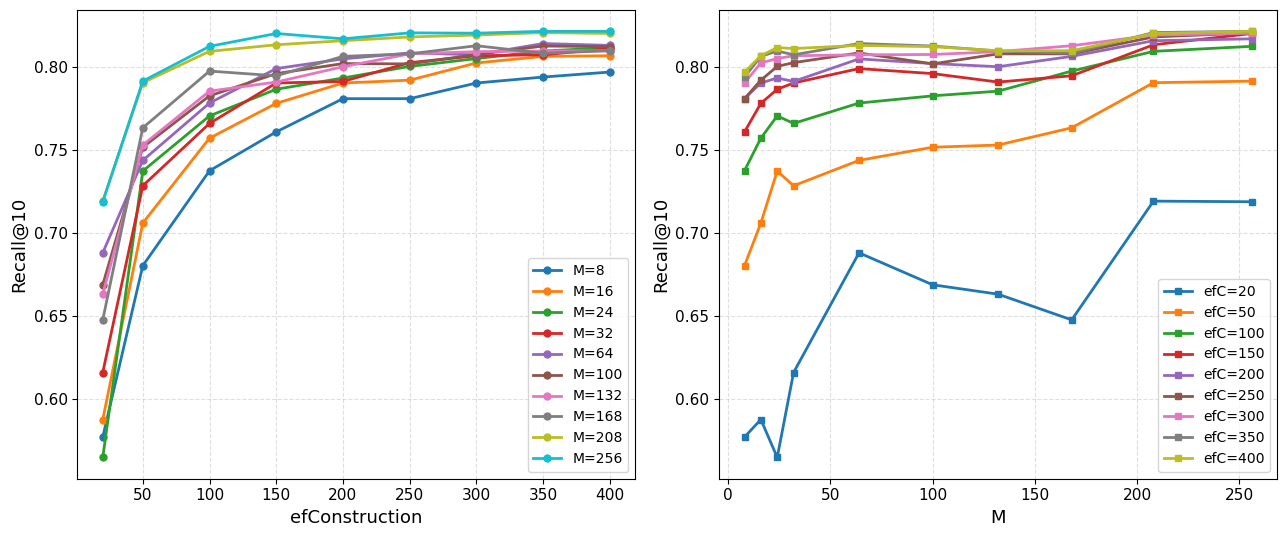

In [131]:
# 新增功能：两幅召回率曲线图
# 图1：所有 M 下，ef_construction 从 20 增至 400 时召回率变化曲线
# 图2：所有 ef_construction 下，M 从 16 增至 256 时召回率变化曲线
recall_grid = np.zeros((len(M_values), len(ef_construction_values)))
idx = 0
for i, M in enumerate(M_values):
    for j, ef_c in enumerate(ef_construction_values):
        recall_grid[i, j] = results_M_efC[idx, 2]
        idx += 1

# 统一设置字体与样式
plt.rcParams.update({"font.size": 11, "axes.labelsize": 12})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), dpi=100)

# 图1：各 M 下，召回率 vs ef_construction
for i, M in enumerate(M_values):
    ax1.plot(ef_construction_values, recall_grid[i, :], marker="o", markersize=5, linewidth=2, label=f"M={M}")
ax1.set_xlabel("efConstruction", fontsize=13)
ax1.set_ylabel(f"Recall@{k_eval}", fontsize=13)
ax1.tick_params(axis="both", labelsize=11)
ax1.legend(loc="lower right", fontsize=10)
ax1.grid(True, alpha=0.4, linestyle="--")

# 单独保存 recall vs efConstruction 曲线
fig1, ax1_only = plt.subplots(figsize=(7, 5), dpi=100)
for i, M in enumerate(M_values):
    ax1_only.plot(ef_construction_values, recall_grid[i, :], marker="o", markersize=5, linewidth=2, label=f"M={M}")
ax1_only.set_xlabel("efConstruction", fontsize=13)
ax1_only.set_ylabel(f"Recall@{k_eval}", fontsize=13)
ax1_only.tick_params(axis="both", labelsize=11)
ax1_only.legend(loc="lower right", fontsize=10)
ax1_only.grid(True, alpha=0.4, linestyle="--")
plt.tight_layout()
fig1.savefig("recall_vs_efconstruction.png", dpi=300, bbox_inches="tight")
plt.close(fig1)

# 图2：各 ef_construction 下，召回率 vs M
for j, ef_c in enumerate(ef_construction_values):
    ax2.plot(M_values, recall_grid[:, j], marker="s", markersize=5, linewidth=2, label=f"efC={ef_c}")
ax2.set_xlabel("M", fontsize=13)
ax2.set_ylabel(f"Recall@{k_eval}", fontsize=13)
ax2.tick_params(axis="both", labelsize=11)
ax2.legend(loc="lower right", fontsize=10)
ax2.grid(True, alpha=0.4, linestyle="--")

plt.tight_layout()
plt.show()

# Recall / 时间 热力图：M x efConstruction（余弦）

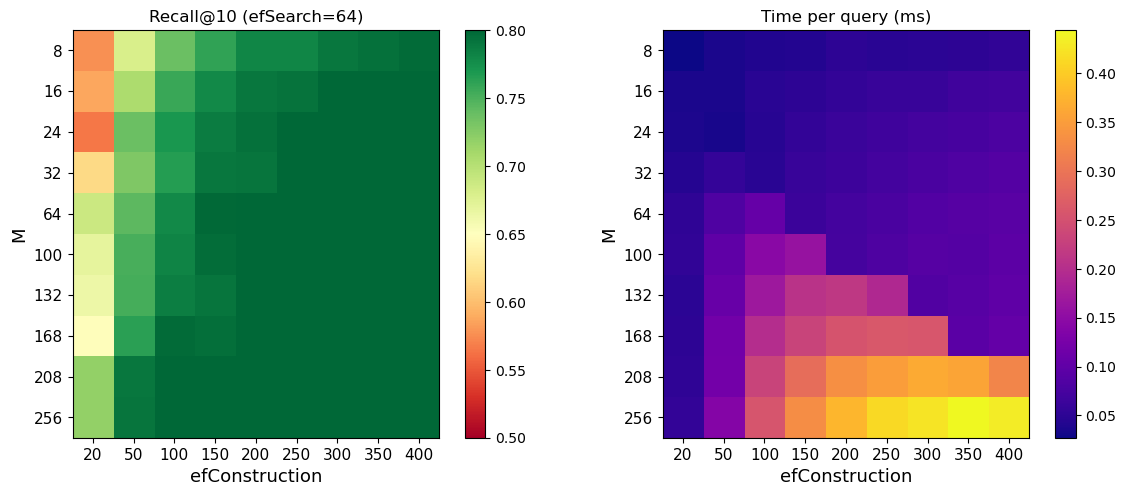

In [132]:
# Recall / 时间 热力图：M x efConstruction（余弦）
recall_grid = np.zeros((len(M_values), len(ef_construction_values)))
time_grid = np.zeros((len(M_values), len(ef_construction_values)))
idx = 0
for i, M in enumerate(M_values):
    for j, ef_c in enumerate(ef_construction_values):
        recall_grid[i, j] = results_M_efC[idx, 2]
        time_grid[i, j] = results_M_efC[idx, 3]
        idx += 1

plt.rcParams.update({"font.size": 11})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=100)

im1 = ax1.imshow(recall_grid, cmap="RdYlGn", vmin=0.5, vmax=0.8)
ax1.set_xticks(range(len(ef_construction_values)))
ax1.set_xticklabels(ef_construction_values, fontsize=11)
ax1.set_yticks(range(len(M_values)))
ax1.set_yticklabels(M_values, fontsize=11)
ax1.set_xlabel("efConstruction", fontsize=13)
ax1.set_ylabel("M", fontsize=13)
ax1.set_title(f"Recall@{k_eval} (efSearch={ef_search_fixed})", fontsize=12)
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.ax.tick_params(labelsize=10)

im2 = ax2.imshow(time_grid, cmap="plasma")
ax2.set_xticks(range(len(ef_construction_values)))
ax2.set_xticklabels(ef_construction_values, fontsize=11)
ax2.set_yticks(range(len(M_values)))
ax2.set_yticklabels(M_values, fontsize=11)
ax2.set_xlabel("efConstruction", fontsize=13)
ax2.set_ylabel("M", fontsize=13)
ax2.set_title("Time per query (ms)", fontsize=12)
cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.ax.tick_params(labelsize=10)

plt.tight_layout()
fig.savefig("recall_time_heatmap.png", dpi=300, bbox_inches="tight")

# 单独保存第二个热力图（查询时间）
fig2, ax_time = plt.subplots(figsize=(8, 6), dpi=300)
im_time = ax_time.imshow(time_grid, cmap="GnBu")
ax_time.set_xticks(range(len(ef_construction_values)))
ax_time.set_xticklabels(ef_construction_values, fontsize=11)
ax_time.set_yticks(range(len(M_values)))
ax_time.set_yticklabels(M_values, fontsize=11)
ax_time.set_xlabel("efConstruction", fontsize=13)
ax_time.set_ylabel("M", fontsize=13)
ax_time.set_title("Time per query (ms)", fontsize=12)
plt.colorbar(im_time, ax=ax_time).ax.tick_params(labelsize=10)
plt.tight_layout()
fig2.savefig("time_heatmap.png", dpi=300, bbox_inches="tight")
plt.close(fig2)

plt.show()

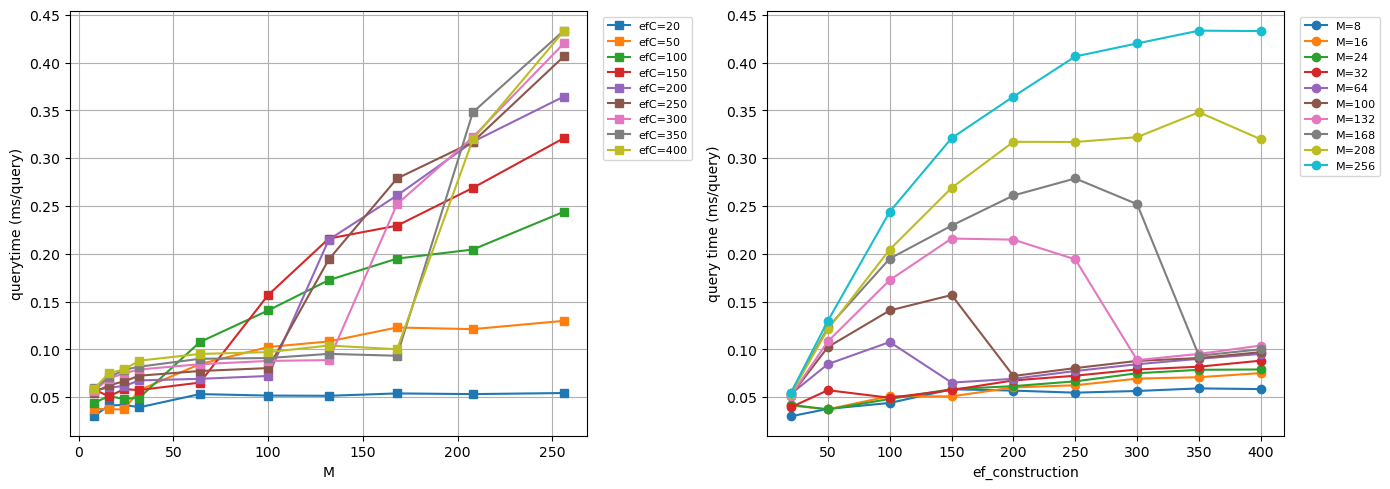

In [81]:
# 图2 & 图3：查询时间曲线
# 需先运行上方 M×efConstruction 网格搜索及热力图 cell，确保 time_grid 已构建
# time_grid[i,j] 对应 M_values[i], ef_construction_values[j]
recall_grid = np.zeros((len(M_values), len(ef_construction_values)))
time_grid = np.zeros((len(M_values), len(ef_construction_values)))
idx = 0
for i, M in enumerate(M_values):
    for j, ef_c in enumerate(ef_construction_values):
        recall_grid[i, j] = results_M_efC[idx, 2]
        time_grid[i, j] = results_M_efC[idx, 3]
        idx += 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 图2：所有 ef_construction 下，M 从 16 增至 256 时查询时间曲线
# X: M, Y: 查询时间(ms), 每条曲线一个 ef_construction
for j, ef_c in enumerate(ef_construction_values):
    ax1.plot(M_values, time_grid[:, j], marker="s", label=f"efC={ef_c}")
ax1.set_xlabel("M")
ax1.set_ylabel("querytime (ms/query)")
# ax1.set_title("图2：M 从 16 增至 256 时查询时间（按 ef_construction 分组）")
ax1.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax1.grid(True)

# 图3：所有 M 下，ef_construction 从 20 增至 400 时查询时间曲线
# X: ef_construction, Y: 查询时间(ms), 每条曲线一个 M
for i, M in enumerate(M_values):
    ax2.plot(ef_construction_values, time_grid[i, :], marker="o", label=f"M={M}")
ax2.set_xlabel("ef_construction")
ax2.set_ylabel("query time (ms/query)")
# ax2.set_title("图3：ef_construction 从 20 增至 400 时查询时间（按 M 分组）")
ax2.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax2.grid(True)

plt.tight_layout()
plt.show()

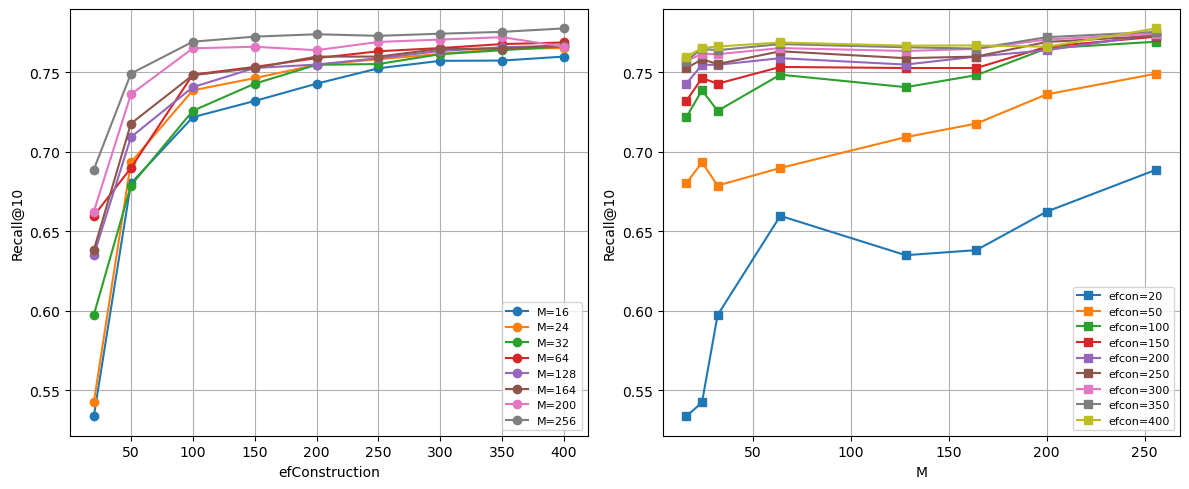

In [ ]:
#新增功能，绘制曲线，两幅图，其中一幅为所有 M 下，ef_construction 从 20 增至 400 时召回率变化曲线，另一幅为所有 ef_construction 下，M 从 16增至 256时召回率变化曲线
# 新增功能：两幅召回率曲线图
# 图1：所有 M 下，ef_construction 从 20 增至 400 时召回率变化曲线
# 图2：所有 ef_construction 下，M 从 16 增至 256 时召回率变化曲线
recall_grid = np.zeros((len(M_values), len(ef_construction_values)))
idx = 0
for i, M in enumerate(M_values):
    for j, ef_c in enumerate(ef_construction_values):
        recall_grid[i, j] = results_M_efC[idx, 2]
        idx += 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 图1：各 M 下，召回率 vs ef_construction
for i, M in enumerate(M_values):
    ax1.plot(ef_construction_values, recall_grid[i, :], marker="o", label=f"M={M}")
ax1.set_xlabel("efConstruction")
ax1.set_ylabel(f"Recall@{k_eval}")
# ax1.set_title("(Cosine) Recall vs efConstruction")
ax1.legend(loc="lower right", fontsize=8)
ax1.grid(True)

# 图2：各 ef_construction 下，召回率 vs M
for j, ef_c in enumerate(ef_construction_values):
    ax2.plot(M_values, recall_grid[:, j], marker="s", label=f"efcon={ef_c}")
ax2.set_xlabel("M")
ax2.set_ylabel(f"Recall@{k_eval}")
# ax2.set_title("(Cosine) Recall vs M")
ax2.legend(loc="lower right", fontsize=8)
ax2.grid(True)

# 图3：所有 M 下，ef_construction 从 20 增至 400 时查询时间曲线


plt.tight_layout()
plt.show()

In [53]:
ef_search_list = [10, 20, 50, 64, 100, 150, 200]
M_list_for_curves = [8, 16, 32]
ef_c_fixed = 150

plt.figure(figsize=(8, 5))
for M in M_list_for_curves:
    recs = []
    for ef_s in ef_search_list:
        index, I, D, t_build, t_search = build_hnsw_and_search_cosine(
            db_descs, query_descs, k_eval,
            M=M, ef_c=ef_c_fixed, ef_s=ef_s
        )
        recs.append(recall_at_k(I, gt_9_list, k_eval, valid_for_metrics))
    plt.plot(ef_search_list, recs, marker="o", label=f"M={M}")

plt.xlabel("efSearch")
plt.ylabel(f"Recall@{k_eval}")
plt.title(f"Recall vs efSearch for different M (efConstruction={ef_c_fixed})")
plt.legend()
plt.grid(False)
plt.show()

KeyboardInterrupt: 

<Figure size 800x500 with 0 Axes>

In [ ]:
#新增暴力检索，给出暴力检索的性能指标：recall@1 recall@5 recall@10 query time


## 6. 小结（余弦相似度）

- 通过对 NetVLAD 向量做 L2 归一化，我们在单位球面上用 L2/HNSW 近似余弦最近邻；
- Ground truth 用 FAISS Flat-IP 暴力检索，直接等价于余弦相似度；
- efSearch、M、efConstruction 对 Recall 与时间的影响，与 L2 情况类似，但数值上略有差异。
